# DX 704 Week 13 Project

This week's project will build a simple agent using language models and tools.
You will integrate the Gemini language model API with custom tools that you create to assist in task automation.


The full project description and a template notebook are available on GitHub: [Project 13 Materials](https://github.com/bu-cds-dx704/dx704-project-13).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 0: Gemini Tool Example

Review the code and its output below to get an idea for how the Gemini API uses tools.

* https://ai.google.dev/gemini-api/docs/tools
* https://ai.google.dev/gemini-api/docs/function-calling

In [1]:
%pip install -q google-genai genanki

Note: you may need to restart the kernel to use updated packages.


In [2]:
import hashlib
import os
import time

import genanki
import matplotlib.pyplot as plt

from google import genai
from google.genai import types


In [3]:
# load the Gemini API key from an environment variable, or prompt for it if not set
gemini_api_key = os.environ.get("GEMINI_API_KEY")
if gemini_api_key is None:
    import getpass
    gemini_api_key = getpass.getpass("Enter your Gemini API key: ")

client = genai.Client(api_key=gemini_api_key)


In [4]:
# list Gemini models
[m.name for m in client.models.list() if "/gemini" in m.name]

['models/gemini-2.5-flash',
 'models/gemini-2.5-pro',
 'models/gemini-2.0-flash',
 'models/gemini-2.0-flash-001',
 'models/gemini-2.0-flash-lite-001',
 'models/gemini-2.0-flash-lite',
 'models/gemini-2.5-flash-preview-tts',
 'models/gemini-2.5-pro-preview-tts',
 'models/gemini-flash-latest',
 'models/gemini-flash-lite-latest',
 'models/gemini-pro-latest',
 'models/gemini-2.5-flash-lite',
 'models/gemini-2.5-flash-image',
 'models/gemini-3-pro-preview',
 'models/gemini-3-flash-preview',
 'models/gemini-3.1-pro-preview',
 'models/gemini-3.1-pro-preview-customtools',
 'models/gemini-3.1-flash-lite-preview',
 'models/gemini-3-pro-image-preview',
 'models/gemini-3.1-flash-image-preview',
 'models/gemini-3.1-flash-tts-preview',
 'models/gemini-robotics-er-1.5-preview',
 'models/gemini-robotics-er-1.6-preview',
 'models/gemini-2.5-computer-use-preview-10-2025',
 'models/gemini-embedding-001',
 'models/gemini-embedding-2-preview',
 'models/gemini-2.5-flash-native-audio-latest',
 'models/gemini

In [5]:
# picked a tool-using model
model_name = "gemini-2.5-flash"

In [6]:
change_light_array_function = {
    "name": "change_light_array",
    "description": "Change the color of a light in a 64x64 array of LEDs.",
    "parameters": {
        "type": "object",
        "properties": {
            "red": {"type": "integer", "description": "Red value of the color."},
            "green": {"type": "integer", "description": "Green value of the color."},
            "blue": {"type": "integer", "description": "Blue value of the color."},
            "x": {"type": "integer", "description": "X coordinate of the light. Must be between 0 and 63 inclusive."},
            "y": {"type": "integer", "description": "Y coordinate of the light. Must be between 0 and 63 inclusive."},
        },
        "required": ["red", "green", "blue"],
    }
}

In [7]:
light_tools = types.Tool(function_declarations=[change_light_array_function])
light_config = types.GenerateContentConfig(tools=[light_tools])

In [9]:
light_response = client.models.generate_content(
    contents="Set the light at 3,3 to be chartreuse.",
    config=light_config,
    model=model_name
)
light_response

GenerateContentResponse(
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            text='I can do that. What are the RGB values for chartreuse?',
            thought_signature=b'\n\x8c\r\x01\xbe>\xf6\xfb\xdc)m\x08\xc1rQ\xde\xf9\xc0\x7f\xbf\xe9\x1b\x80T\x88\xfc~\xe0\x15\xe3M\x0c\x08i\xfe\xe7\xf0\x94?\xcd\xfc\xec\x06\xc0\x9bvR\xdf\xffO\xfe$\x0b\x17I\xbfxU\x84\x8d\xaee\x93\x8b\xc4\xddx\xcd$\xf5;w\x7f\xfc3\xac\x8c\xdd\x01Os\x8a\xee\x90B\x12\x80T\x83\xa9\x17soB\x88\xefm...'
          ),
        ],
        role='model'
      ),
      finish_reason=<FinishReason.STOP: 'STOP'>,
      index=0
    ),
  ],
  model_version='gemini-2.5-flash',
  response_id='-93gafabIO2sqtsPgMelqA0',
  sdk_http_response=HttpResponse(
    headers=<dict len=12>
  ),
  usage_metadata=GenerateContentResponseUsageMetadata(
    candidates_token_count=14,
    prompt_token_count=165,
    prompt_tokens_details=[
      ModalityTokenCount(
        modality=<MediaModality.TEXT: 'TEXT'>,
 

In [10]:
light_response.candidates[0].content.parts[0].function_call

## Part 1: Implement Agent Logging

The Agent class below uses the Gemini API's tool support to provide a chat interface that can use tools.
Modify the Agent class to save a transcript with the name AGENT_NAME.txt where AGENT_NAME is the name used when creating the Agent object.
Anything in the `contents` list inside the `run` method should be saved to that file.
Test your code with the `plain_agent` setup below.

In [11]:
class Agent(object):
    def __init__(self, name, introduction, prompt, model="gemini-2.5-flash"):
        self.name = name
        self.introduction = introduction
        self.prompt = prompt
        self.model = model

        self.function_declarations = {}
        self.functions = {}

    def predict(self, contents, **kwargs):
        kwargs.setdefault("model", self.model)

        # retry on transient server errors (like 503 UNAVAILABLE from overloaded models)
        max_attempts = 5
        wait_seconds = 2
        for attempt_number in range(1, max_attempts + 1):
            try:
                return client.models.generate_content(contents=contents, **kwargs)
            except Exception as api_error:
                error_message = str(api_error)
                is_retryable = "503" in error_message or "UNAVAILABLE" in error_message or "500" in error_message or "429" in error_message
                if is_retryable and attempt_number < max_attempts:
                    print(f"API error (attempt {attempt_number}/{max_attempts}), retrying in {wait_seconds}s: {error_message[:120]}")
                    time.sleep(wait_seconds)
                    wait_seconds = wait_seconds * 2
                else:
                    raise

    def register_tool(self, function, **function_declaration):
        if "name" not in function_declaration:
            function_declaration["name"] = function.__name__

        function_name = function_declaration["name"]
        assert "description" in function_declaration
        assert "parameters" in function_declaration

        self.function_declarations[function_name] = function_declaration
        self.functions[function_name] = function

    def save_transcript(self, contents):
        # write every entry from the contents list to a transcript file named <agent_name>.txt
        transcript_file_name = f"{self.name}.txt"
        with open(transcript_file_name, "w") as transcript_file:
            for single_entry in contents:
                transcript_file.write(str(single_entry) + "\n")

    def run(self):
        print("RUNNING WITH TOOLS", list(self.functions.keys()))
        tools = types.Tool(function_declarations=list(self.function_declarations.values()))
        config = types.GenerateContentConfig(tools=[tools])

        print(self.introduction, "\n\n")

        contents = []
        try:
            while True:
                p = input("> ")
                if p.strip().lower() in ("stop", "quit", "exit"):
                    break

                contents.append(p)

                # if the API call fails even after retries, save what we have and keep the loop alive
                try:
                    response = self.predict(
                        contents=contents,
                        config=config
                    )
                except Exception as api_error:
                    print(f"API call failed: {api_error}")
                    print("Your input was saved. Try sending another message or type 'exit'.")
                    self.save_transcript(contents)
                    continue

                for new_content_part in response.candidates[0].content.parts:
                    if new_content_part.text:
                        print("TEXT", new_content_part.text)
                        contents.append(new_content_part.text)
                    elif new_content_part.function_call:
                        call = new_content_part.function_call
                        print("FUNCTION CALL", call)
                        if call.name in self.functions:
                            output = self.functions[call.name](**call.args)
                            if output:
                                print("OUTPUT", output)
                                contents.append(output)
                        else:
                            print("UNRECOGNIZED FUNCTION", call.name)
                    else:
                        print("UNKNOWN", new_content_part)

                # save after each full turn so a later crash still leaves a usable file
                self.save_transcript(contents)
        finally:
            # guarantee the transcript is written no matter how the loop exits
            self.save_transcript(contents)
            print(f"Transcript saved to {self.name}.txt")


In [12]:
plain_agent = Agent(name="plain",
                    introduction="Hi, I am PlainGPT and I have no tools.",
                    prompt="You are a helpful agent that is eager to help but you have no tools.")

In [13]:
plain_agent.run()

RUNNING WITH TOOLS []
Hi, I am PlainGPT and I have no tools. 


API error (attempt 1/5), retrying in 2s: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand 
API error (attempt 2/5), retrying in 4s: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand 
API error (attempt 3/5), retrying in 8s: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand 
TEXT Hi there! How can I help you today?
API error (attempt 1/5), retrying in 2s: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand 
TEXT Humans first went to the Moon on **July 20, 1969**, as part of the **Apollo 11** mission.

Neil Armstrong was the first person to step onto the lunar surface, followed by Buzz Aldrin.
API error (attempt 1/5), retrying in 2s: 503 UNAVAILABLE. 

Submit "plain.txt" in Gradescope.

## Part 2: Test the Agent Code

Use the color agent below and instruct the agent to show you the colors blue, red, and cyan.
After the agent has shown those colors, make sure to end the `run` method cleanly by telling the agent stop, quit, or exit.


You will notice that the language model's behavior is different from other language models or even normal Gemini since it is working with a restricted set of tools.
You may change the agent code if you wish (e.g. to change the model or give it more tools), but be careful not to change the information stored to the contents list and the log file.


Hint: The RGB values for blue are (0, 0, 255), the RGB values for red are (255, 0, 0) and the RGB values for cyan are (0, 255, 255).
The auto-grader will be checking for those values in your log file, so make sure that the agent shows you the right colors.
Ideally, you can get it to figure out those values on its own, but in the worst case you can tell the agent the RGB values.

In [15]:
def show_color(red, green, blue):
    plt.imshow([[[red, green, blue]]])
    plt.axis('off')
    plt.show()
    return f"Red: {red}, Green: {green}, Blue: {blue}"

color_agent = Agent(name="color",
                    introduction="Hi, I am ColorGPT and I know every color.",
                    prompt="You are a helpful agent that is eager to show off your color knowledge.")
color_agent.register_tool(show_color,
                          description="Show a color!",
                          parameters = {"type": "object",
                                         "properties": {
                                             "red": {"type": "integer", "description": "Red value of the color."},
                                             "green": {"type": "integer", "description": "Green value of the color."},
                                             "blue": {"type": "integer", "description": "Blue value of the color."}
                                         }, "required": ["red", "green", "blue"]})

RUNNING WITH TOOLS ['show_color']
Hi, I am ColorGPT and I know every color. 


FUNCTION CALL id=None args={'green': 0, 'red': 0, 'blue': 255} name='show_color' partial_args=None will_continue=None


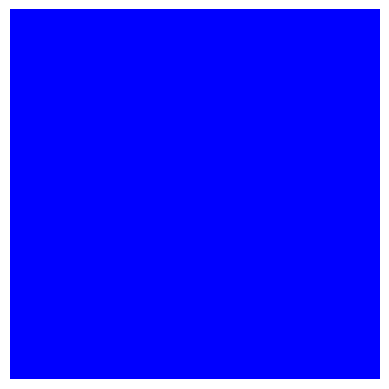

OUTPUT Red: 0, Green: 0, Blue: 255
FUNCTION CALL id=None args={'red': 0, 'blue': 255, 'green': 0} name='show_color' partial_args=None will_continue=None


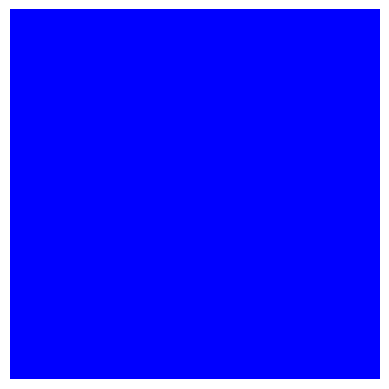

OUTPUT Red: 0, Green: 0, Blue: 255
API error (attempt 1/5), retrying in 2s: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand 
FUNCTION CALL id=None args={'red': 255, 'blue': 0, 'green': 0} name='show_color' partial_args=None will_continue=None


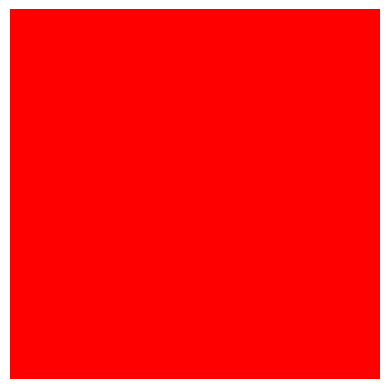

OUTPUT Red: 255, Green: 0, Blue: 0
FUNCTION CALL id=None args={'blue': 255, 'green': 255, 'red': 0} name='show_color' partial_args=None will_continue=None


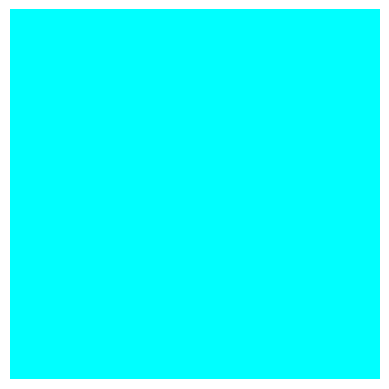

OUTPUT Red: 0, Green: 255, Blue: 255
Transcript saved to color.txt


In [16]:
color_agent.run()

Submit "color.txt" in Gradescope.

## Part 3: Modify Anki Flashcard Agent

[Anki](https://apps.ankiweb.net/) is a program to help memorization using Flashcards.
(Professor Considine uses Anki to learn foreign language vocabulary.)
The agent that follows can create an Anki "deck" and add notes to create flashcards.
However, the save functionality has not yet been integrated as a tool for the agent.
Implement that functionality and then test it by instructing the agent to save an empty deck as "empty.apkg".

In [17]:
# Simple Model setup from https://github.com/kerrickstaley/genanki?tab=readme-ov-file#models
# this defines a model of flashcards with just two fields, question for the front, and answer for the back.

simple_model = genanki.Model(
    1607392319,
    'Simple Model',
    fields=[
        {'name': 'Question'},
        {'name': 'Answer'},
    ],
    templates=[
        {
        'name': 'Card 1',
        'qfmt': '{{Question}}',
        'afmt': '{{FrontSide}}<hr id="answer">{{Answer}}',
        },
    ])

In [18]:
anki_decks = {}

In [19]:
def get_deck(deck_name):
    if deck_name not in anki_decks:
        hash = hashlib.sha256(deck_name.encode('utf-8')).hexdigest()
        hash = hash[:12]
        hash = int(hash, 16)
        anki_decks[deck_name] = genanki.deck.Deck(deck_id=hash, name=deck_name)
        anki_decks[deck_name].add_model(simple_model)

    return anki_decks[deck_name]

get_deck("test")

In [20]:
anki_agent = Agent(name="anki",
                   introduction="Hi, I am AnkiGPT and I can help you build Anki flashcard decks.",
                   prompt="You are a helpful AI that helps lookup content for flashcards and then makes the flashcards.")

In [21]:
def create_anki_note(front, back, deck):
    get_deck(deck).add_note(genanki.Note(model=simple_model, fields=[front, back]))
    return f"Created note in Anki deck {deck!r}"

anki_agent.register_tool(create_anki_note,
    description="Create a note in an Anki flashcard deck.",
    parameters= {
        "type": "object",
        "properties": {
            "front": {"type": "string", "description": "Content for front side of flash card."},
            "back": {"type": "string", "description": "Content for back side of flash card."},
            "deck": {"type": "string", "description": "Name of the Anki deck to add the note to."},
        },
        "required": ["front", "back", "deck"],
    })


In [22]:
def save_anki_deck(deck):
    genanki.Package(get_deck(deck)).write_to_file(f"{deck}.apkg")
    return f"Saved Anki deck {deck!r} to file."


In [23]:
# register the save_anki_deck function so the agent can save a deck to a .apkg file
anki_agent.register_tool(save_anki_deck,
    description="Save an Anki flashcard deck to a .apkg file. The file will be named after the deck.",
    parameters={
        "type": "object",
        "properties": {
            "deck": {"type": "string", "description": "Name of the Anki deck to save."},
        },
        "required": ["deck"],
    })


In [24]:
anki_agent.run()

RUNNING WITH TOOLS ['create_anki_note', 'save_anki_deck']
Hi, I am AnkiGPT and I can help you build Anki flashcard decks. 


API error (attempt 1/5), retrying in 2s: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand 
API error (attempt 2/5), retrying in 4s: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand 
FUNCTION CALL id=None args={'deck': 'empty'} name='save_anki_deck' partial_args=None will_continue=None
OUTPUT Saved Anki deck 'empty' to file.
Transcript saved to anki.txt


Submit "empty.apkg" in Gradescope.

## Part 4: Make an Anki Deck with Flashcards

Run the Anki agent again, and instruct it to make 10 flashcards on a topic of your choice.
If possible, have the agent supply the answers to your questions.
When you are done, save the deck with an appropriate name (but not "empty.apkg").

In [26]:
anki_agent.run()

RUNNING WITH TOOLS ['create_anki_note', 'save_anki_deck']
Hi, I am AnkiGPT and I can help you build Anki flashcard decks. 


FUNCTION CALL id=None args={'deck': 'corgi_facts', 'back': 'Wales, United Kingdom', 'front': 'Where do Corgis originate from?'} name='create_anki_note' partial_args=None will_continue=None
OUTPUT Created note in Anki deck 'corgi_facts'
FUNCTION CALL id=None args={'back': 'Pembroke Welsh Corgi and Cardigan Welsh Corgi', 'deck': 'corgi_facts', 'front': 'What are the two main breeds of Corgis?'} name='create_anki_note' partial_args=None will_continue=None
OUTPUT Created note in Anki deck 'corgi_facts'
FUNCTION CALL id=None args={'front': 'What was the original purpose of Corgis?', 'deck': 'corgi_facts', 'back': 'Herding cattle, sheep, and ponies'} name='create_anki_note' partial_args=None will_continue=None
OUTPUT Created note in Anki deck 'corgi_facts'
FUNCTION CALL id=None args={'back': '12-15 years', 'deck': 'corgi_facts', 'front': 'What is the average lifespan o

Submit "anki.txt" from making flashcards and the .apkg file with your flashcards in Gradescope.

## Part 5: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.
You do not need to provide code for data collection if you did that by manually.

## Part 6: Acknowledgements

If you discussed this assignment with anyone, please acknowledge them here.
If you did this assignment completely on your own, simply write none below.

If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for. If you did not use any other libraries, simply write none below.

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy. If you did not use any generative AI tools, simply write none below.